In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Validación del dataset

# Descripción de las Variables del Dataset

- **RowNumber**  
  Corresponde al número de fila del dataset y no tiene impacto en el abandono de clientes (churn).

- **CustomerId**  
  Identificador único asignado a cada cliente. Contiene valores aleatorios y no es útil para la predicción.

- **Surname**  
  Apellido del cliente.

- **CreditScore**  
  Puntuación crediticia del cliente. Una puntuación más alta puede indicar clientes financieramente más estables, reduciendo potencialmente la probabilidad de abandono.

- **Balance**  
  Cantidad de dinero disponible en la cuenta bancaria del cliente. Los clientes con balances más altos pueden ser menos propensos a abandonar el banco.

- **EstimatedSalary**  
  Salario anual estimado del cliente. El nivel salarial podría influir en la retención de clientes.

- **Points Earned**  
  Puntos de recompensa acumulados por el cliente mediante el uso de la tarjeta de crédito.

- **Geography**  
  País donde se encuentra el cliente. La ubicación geográfica puede influir en los patrones de abandono.

- **Gender**  
  Género del cliente. Útil para analizar posibles diferencias de comportamiento.

- **Age**  
  Edad del cliente. La edad suele ser un factor importante en el análisis de retención de clientes.

- **Tenure**  
  Número de años que el cliente ha permanecido en el banco. Los clientes con mayor antigüedad suelen ser más leales.

- **NumOfProducts**  
  Número de productos bancarios contratados por el cliente.

- **HasCrCard**  
  Indica si el cliente posee una tarjeta de crédito.

- **IsActiveMember**  
  Indica si el cliente es considerado un miembro activo del banco.

- **Card Type**  
  Tipo de tarjeta de crédito que posee el cliente (por ejemplo: Gold, Silver, Platinum).

- **Complain**  
  Indica si el cliente ha presentado una queja o reclamación.

- **Satisfaction Score**  
  Puntuación de satisfacción proporcionada tras la resolución de una reclamación.

- **Exited**  
  Indica si el cliente abandonó el banco.

  - `0` → El cliente permaneció en el banco  
  - `1` → El cliente abandonó el banco

In [2]:
df = pd.read_csv("../data/raw/Bank-Customer-Churn.csv")

In [6]:
# Lectura basica de como se vé el dataset
print("Shape del dataset:", df.shape) # (10000 rows, 18 col)
print("\nCantidad de duplicados: ",df.duplicated().sum())
print("\nInformación del dataset:")
print(df.info())
df.head()

Shape del dataset: (10000, 18)

Cantidad de duplicados:  0

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain          

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [9]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [7]:
# el dataset viene limpio y sin duplicados
print("\nCantidad de valores nulos por columna:")
print(df.isnull().sum())


Cantidad de valores nulos por columna:
RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64


## Analizamos el target Exited

In [ ]:
print("\nPorcentaje de cada clase:")
# balance de targets
print(df["Exited"].value_counts(normalize=True) * 100)

Exited
0    7962
1    2038
Name: count, dtype: int64

Porcentaje de cada clase:
Exited
0    79.62
1    20.38
Name: proportion, dtype: float64


### Distribución por categorías

In [12]:
print(df["Geography"].value_counts())
print("\nCantidad de cada género:")
print(df["Gender"].value_counts())
print("\nPorcentaje de cada país:")
print(df["Geography"].value_counts(normalize=True) * 100)

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Cantidad de cada género:
Gender
Male      5457
Female    4543
Name: count, dtype: int64

Porcentaje de cada país:
Geography
France     50.14
Germany    25.09
Spain      24.77
Name: proportion, dtype: float64


### Crosstabs

In [ ]:
# Churn por pais
pd.crosstab(
    df["Geography"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
Geography,,
France,83.825289,16.174711
Germany,67.556796,32.443204
Spain,83.326605,16.673395


In [14]:
# Churn por género
pd.crosstab(
    df["Gender"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.525747,16.474253


In [ ]:
# Churn por actividad
pd.crosstab(
    df["IsActiveMember"],
    df["Exited"],
    normalize="index"
) * 100

Exited,0,1
IsActiveMember,,
0,73.128480,26.871520
1,85.730926,14.269074


In [ ]:
# Colores que usaré
BANK_BLUE = "#0A2540"
BANK_RED = "#8B1E3F"
sns.set_style("whitegrid")

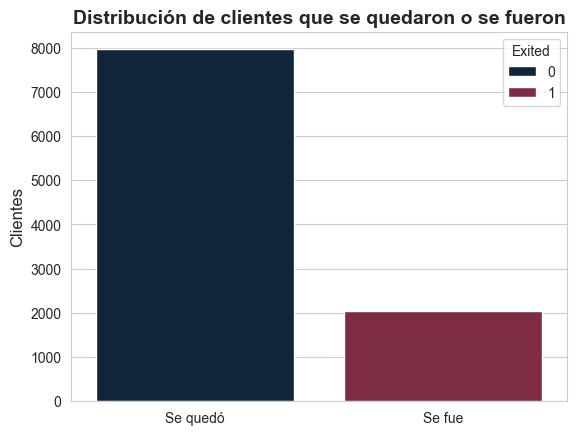

In [ ]:
# ver los usuarios que se fueron o quedaron
sns.countplot(
    data=df, 
    x="Exited",
    hue="Exited",
    palette=[BANK_BLUE, BANK_RED])

plt.xticks(
    [0, 1],
    ["Se quedó", "Se fue"]
)
plt.title("Distribución de clientes que se quedaron o se fueron", fontsize=14, fontweight="bold")
plt.xlabel("")
plt.ylabel("Clientes", fontsize=12)

plt.savefig(
    "../reports/figures/Churn_Customers.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

El dataset presenta un desbalance moderado: la mayoría de clientes permanecen en el banco, mientras que una minoría abandona el servicio. 

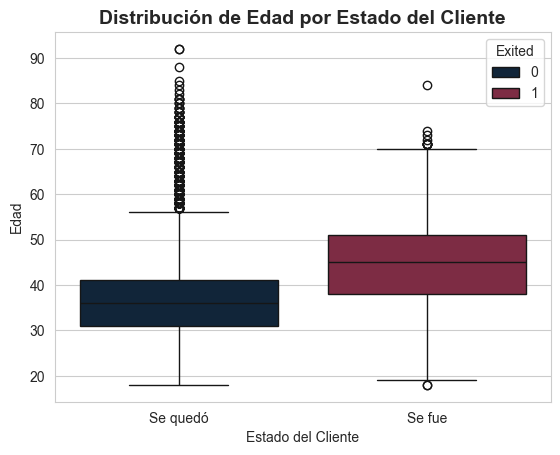

In [ ]:
# distribuión de edades por churn
sns.boxplot(
    data=df,
    x="Exited",
    y="Age",
    hue="Exited",
    palette=[BANK_BLUE, BANK_RED]
)
plt.xticks(
    [0, 1],
    ["Se quedó", "Se fue"]
)
plt.xlabel("Estado del Cliente")
plt.ylabel("Edad")

plt.title("Distribución de Edad por Estado del Cliente", fontsize=14, fontweight="bold")

plt.savefig(
    "../reports/figures/Edad_Distribucion_Estado_Cliente.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Los clientes que abandonan el banco presentan una mediana de edad superior. Esto sugiere que la edad podría estar relacionada con una mayor probabilidad de churn.

También se observan varios outliers en edades altas, especialmente en clientes que permanecen en el banco.

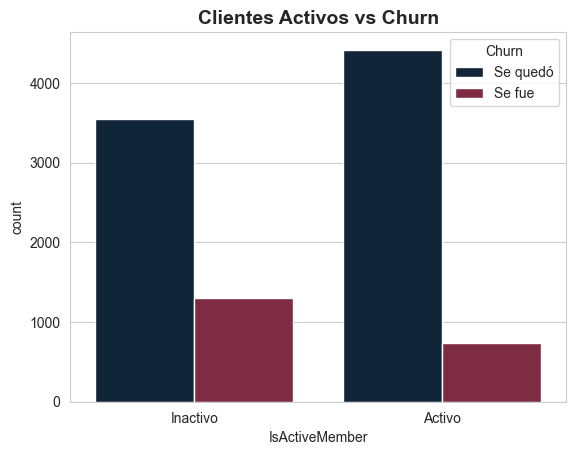

In [ ]:

# ver si los clientes activos se van o no
sns.countplot(
    data=df,
    x="IsActiveMember",
    hue="Exited",
    palette=[BANK_BLUE, BANK_RED]
)

plt.xticks([0, 1], ["Inactivo", "Activo"])

plt.legend(
    title="Churn",
    labels=["Se quedó", "Se fue"]
)

plt.title("Clientes Activos vs Churn", fontsize=14, fontweight="bold")

plt.savefig(
    "../reports/figures/Clientes_Activos_vs_Churn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Podría parecer que los clientes activos abandonan más el banco, pero esto se debe a que existen más clientes activos en el dataset.
Analizando las proporciones, los clientes inactivos tienen una tasa de abandono considerablemente mayor.

### Matriz de correlación

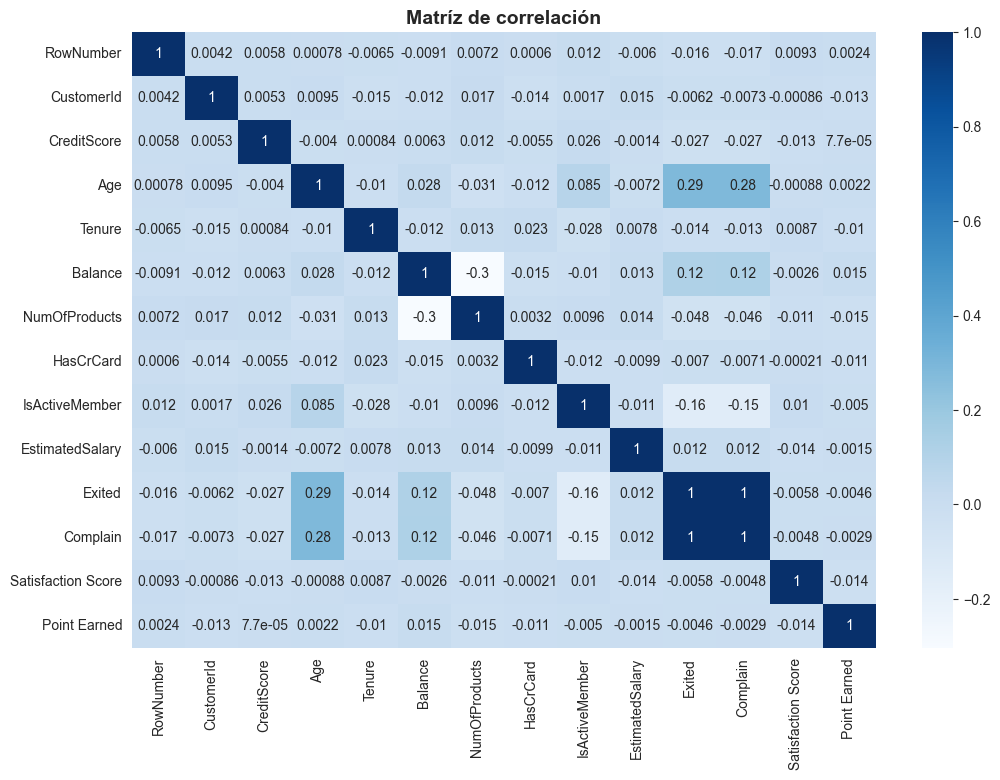

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Matríz de correlación", fontsize=14, fontweight="bold")

plt.savefig(
    "../reports/figures/Matriz_Correlacion.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Hay un posible data leakage

La variable Complain presenta una correlación perfecta con la variable objetivo (Exited).

Esto podría indicar data leakage, ya que la información contenida en esta variable parece revelar directamente si el cliente abandonó el banco.

Por este motivo, se va a eliminar esta variable durante la fase de modelado para evitar resultados artificialmente altos.

## Distribuciones numéricas

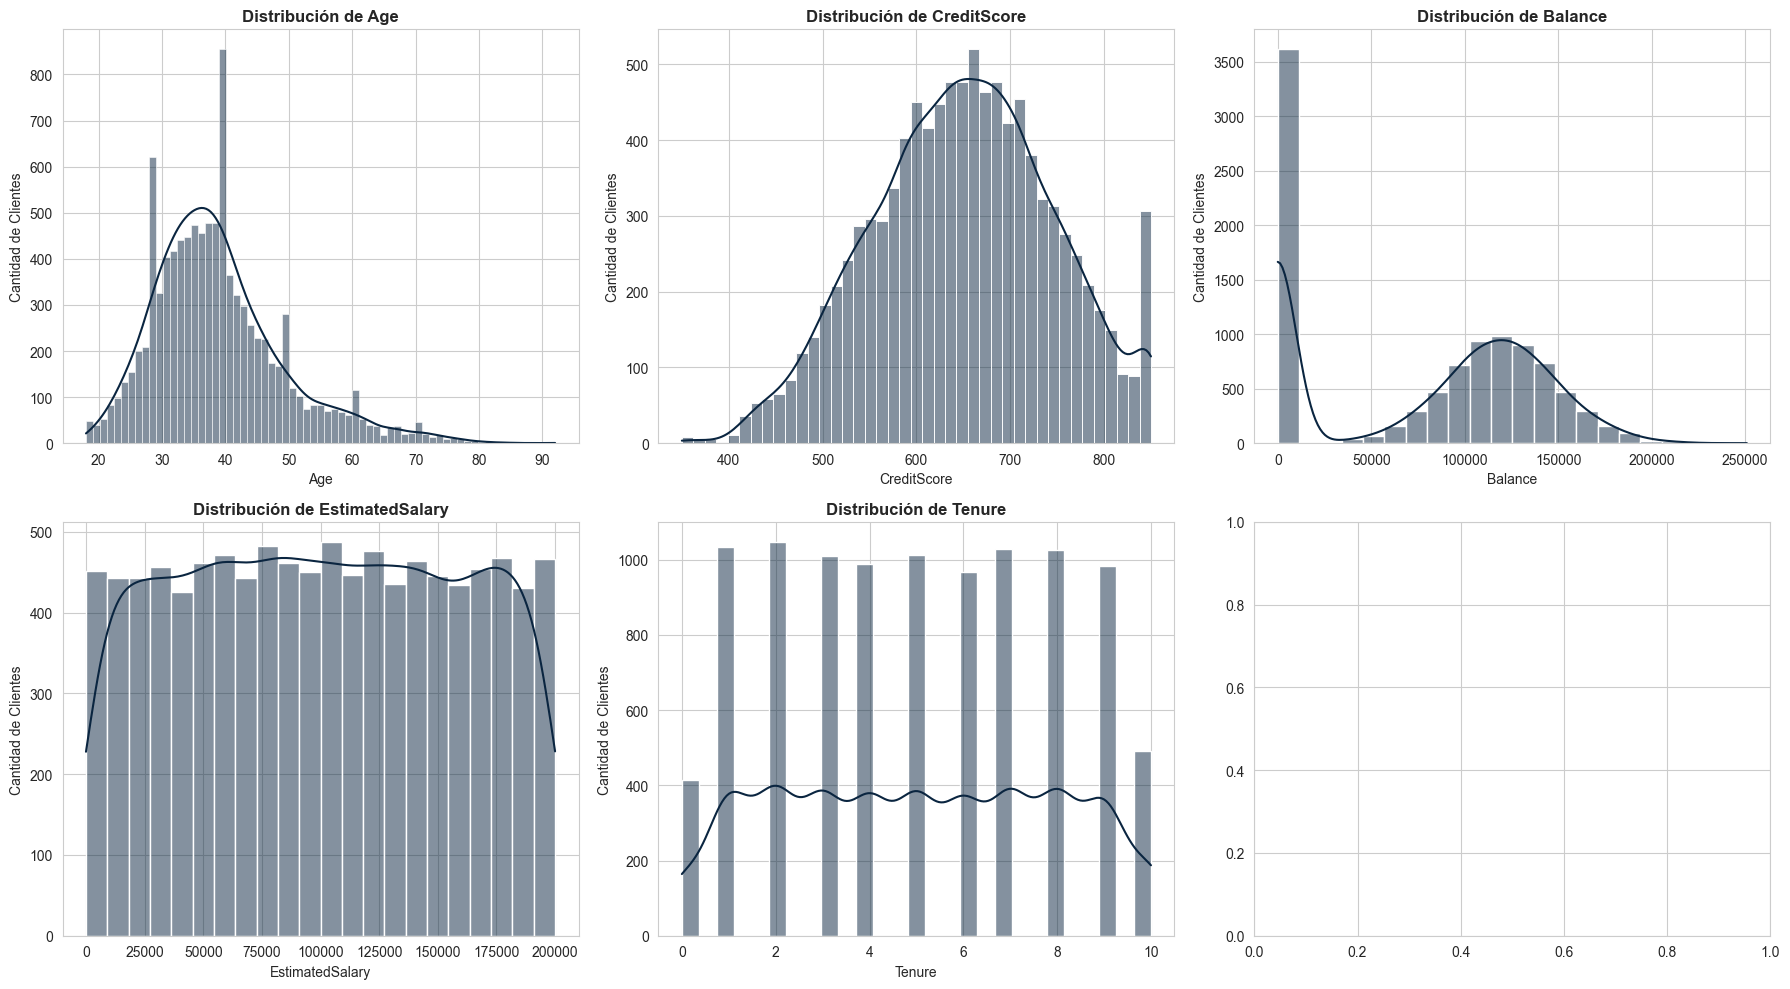

In [ ]:
numerical_cols = [
    "Age",
    "CreditScore",
    "Balance",
    "EstimatedSalary",
    "Tenure"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        color=BANK_BLUE,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Distribución de {col}",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Cantidad de Clientes")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Distribuciones_Numericas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Age

- La mayoría de clientes se concentran entre los 30 y 45 años, con una ligera asimetría hacia edades mayores.

CreditScore

- El credit score sigue una distribución aproximadamente normal centrada en valores medios, sin una concentración extrema en puntuaciones bajas.

Balance

- Se observa una gran cantidad de clientes con balance cercano a 0, mientras que el resto se distribuye alrededor de valores medios-altos.

EstimatedSalary

- La variable salario estimado presenta una distribución bastante uniforme, sin concentraciones claras.

Tenure

- La antigüedad de clientes se distribuye de manera relativamente homogénea entre los distintos años.

## Variables Categóricas

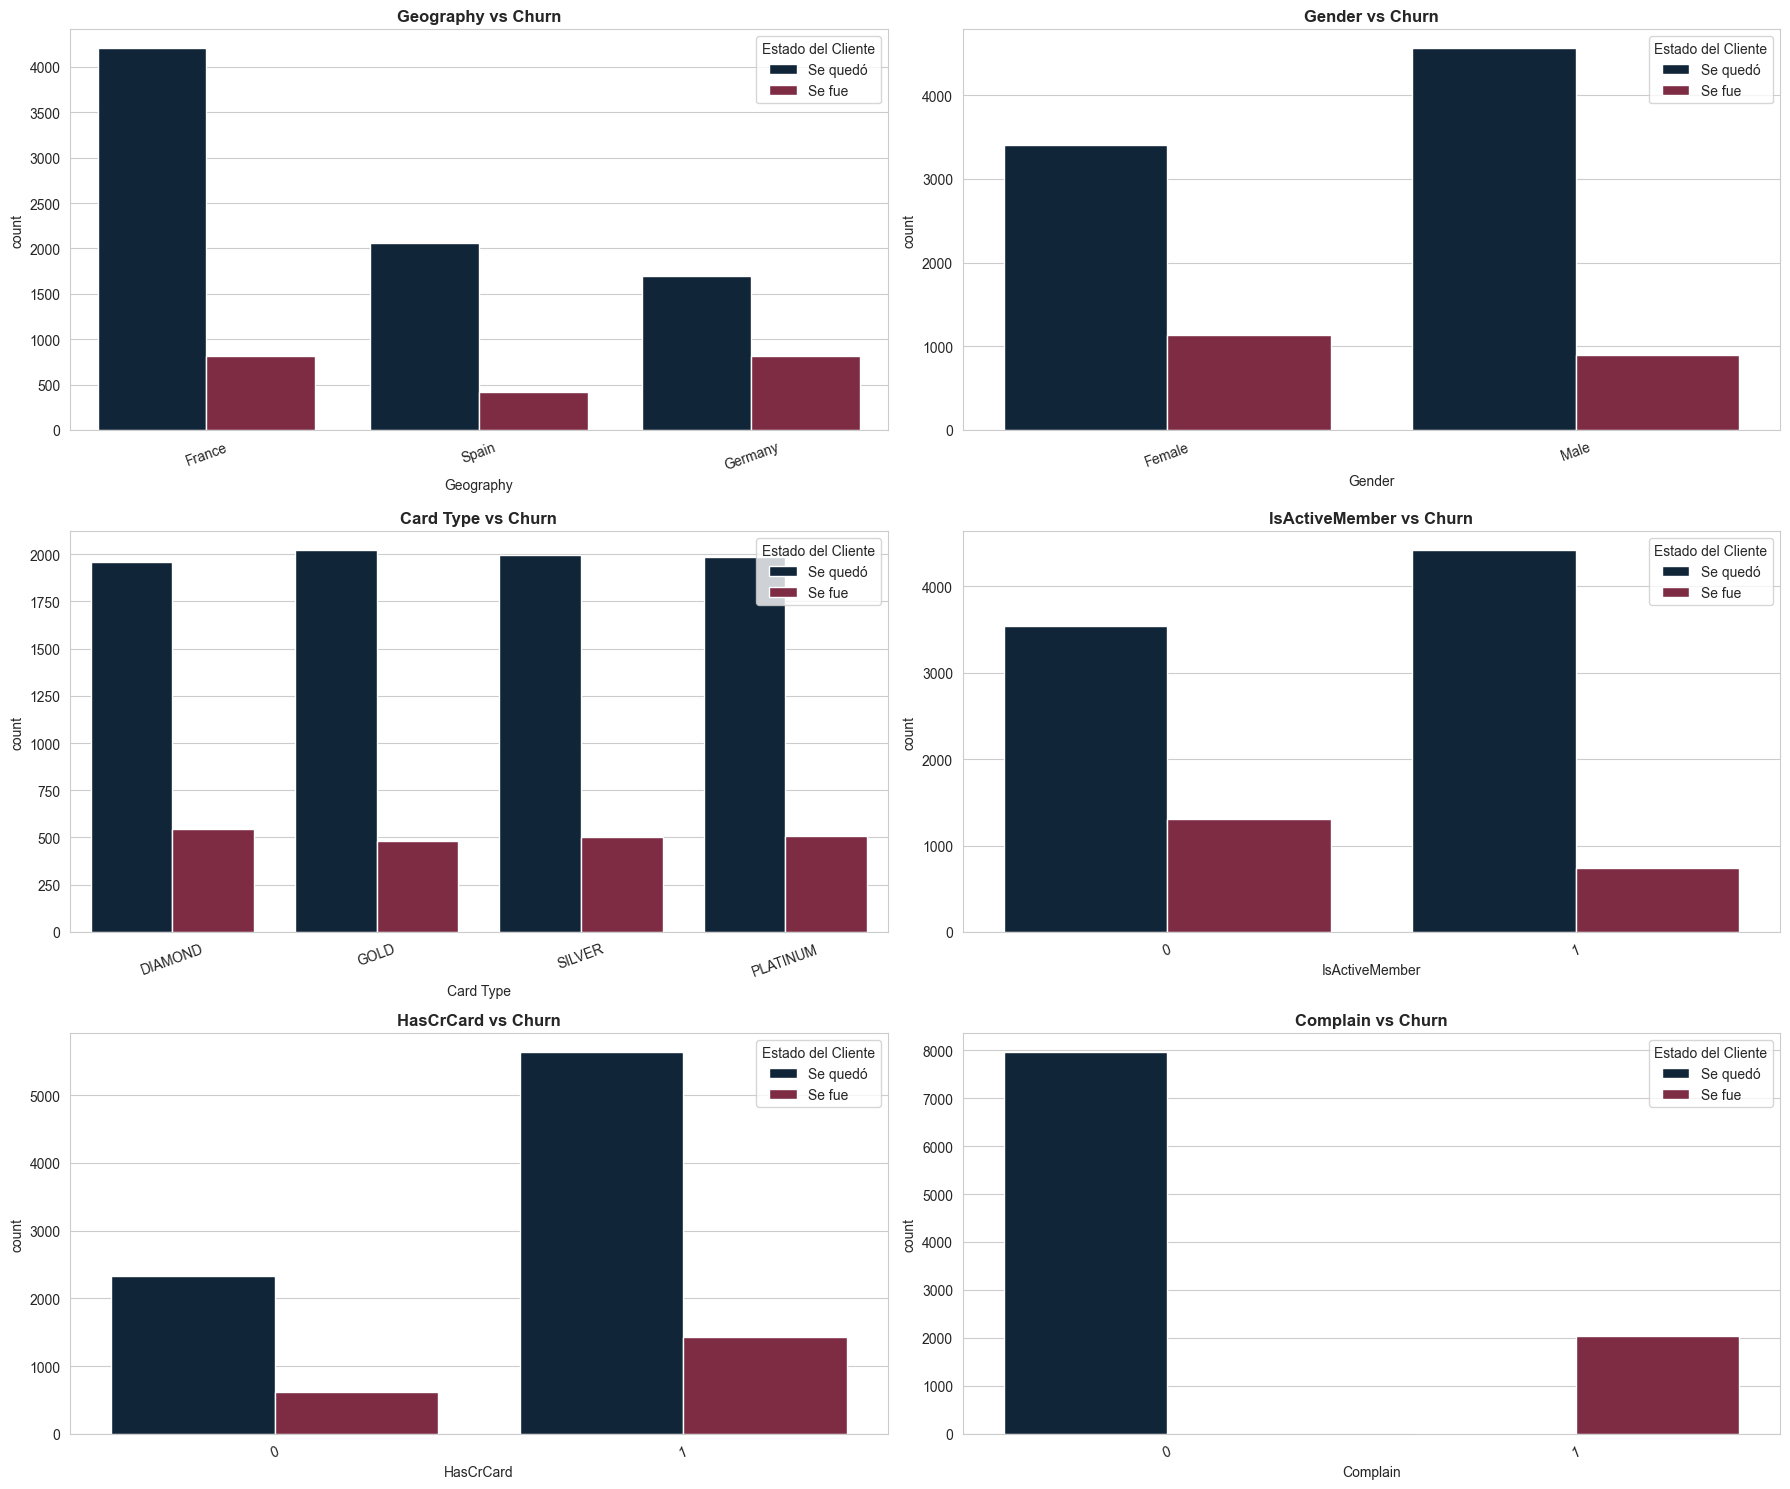

In [ ]:
categorical_cols = [
    "Geography",
    "Gender",
    "Card Type",
    "IsActiveMember",
    "HasCrCard",
    "Complain"
]

fig, axes = plt.subplots(3, 2, figsize=(18, 15))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    sns.countplot(
        data=df,
        x=col,
        hue="Exited",
        palette=[BANK_BLUE, BANK_RED],
        ax=axes[i]
    )

    axes[i].set_title(
        f"{col} vs Churn",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].tick_params(axis="x", rotation=20)

    axes[i].legend(
        title="Estado del Cliente",
        labels=["Se quedó", "Se fue"]
    )

plt.tight_layout()

plt.savefig(
    "../reports/figures/Churn_Categorico.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Geography vs churn

- Alemania presenta una proporción de churn superior respecto a Francia y España, lo que podría indicar diferencias de comportamiento entre mercados.

Gender vs churn

- Las mujeres muestran una tasa de abandono ligeramente mayor que los hombres.

Card Type vs churn

- No se observan diferencias especialmente marcadas entre tipos de tarjeta, por lo que esta variable podría tener menor impacto predictivo.

IsActiveMember vs churn

- La actividad del cliente parece tener una relación fuerte con el churn: los clientes activos abandonan significativamente menos.

HasCrCard vs churn

- Tener tarjeta de crédito no parece generar diferencias importantes en el abandono de clientes.

Complain vs churn

- Existe una relación muy fuerte entre reclamaciones y churn: prácticamente todos los clientes que realizaron una queja terminaron abandonando el banco.

## Boxplot vs Churn

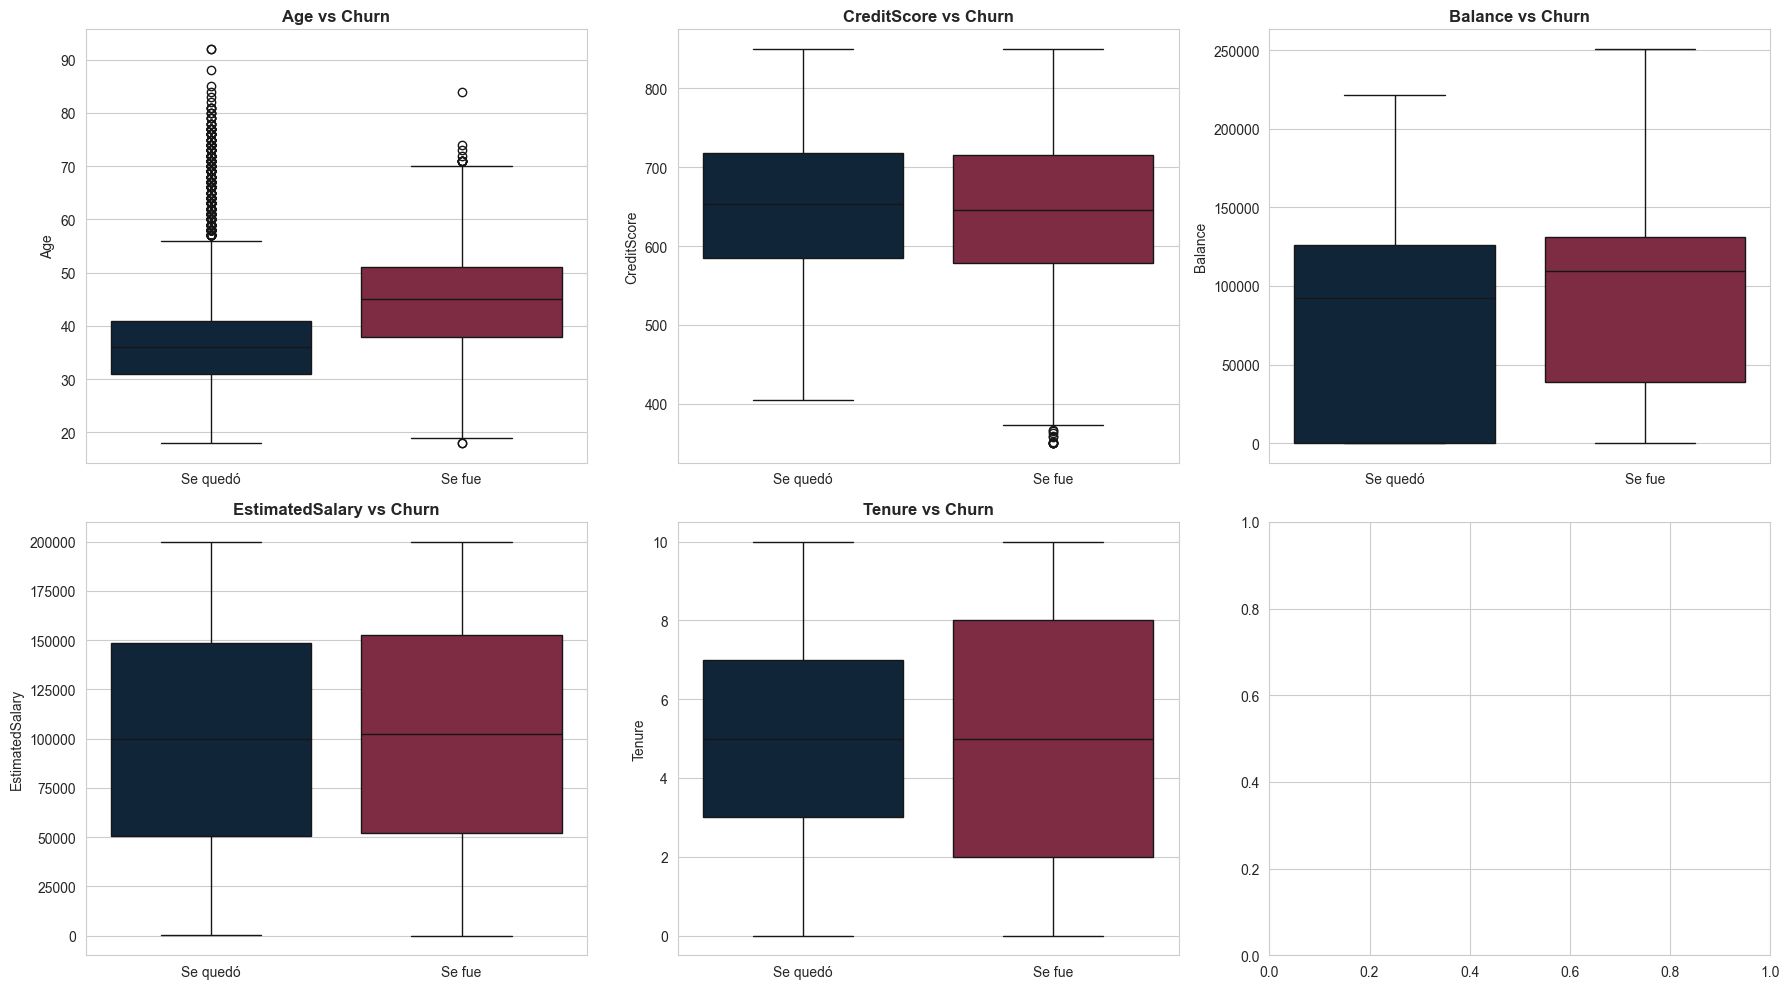

In [ ]:

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        data=df,
        x="Exited",
        y=col,
        hue="Exited",
        palette=[BANK_BLUE, BANK_RED],
        legend=False,
        ax=axes[i]
    )

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Se quedó", "Se fue"])

    axes[i].set_title(
        f"{col} vs Churn",
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel("")
    axes[i].set_ylabel(col)

plt.tight_layout()

plt.savefig(
    "../reports/figures/Churn_Boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Age vs churn

- Los clientes que abandonan el banco tienden a tener edades más elevadas que aquellos que permanecen.

CreditScore vs churn

- No se observan diferencias muy pronunciadas entre las distribuciones de credit score de ambos grupos.

Balance vs churn

- Los clientes que abandonan el banco presentan balances ligeramente superiores en comparación con los que permanecen.

EstimatedSalary vs churn

- El salario estimado no parece mostrar una relación clara con el churn.

Tenure vs churn

- La antigüedad no presenta diferencias especialmente marcadas entre clientes que abandonan y clientes que permanecen.